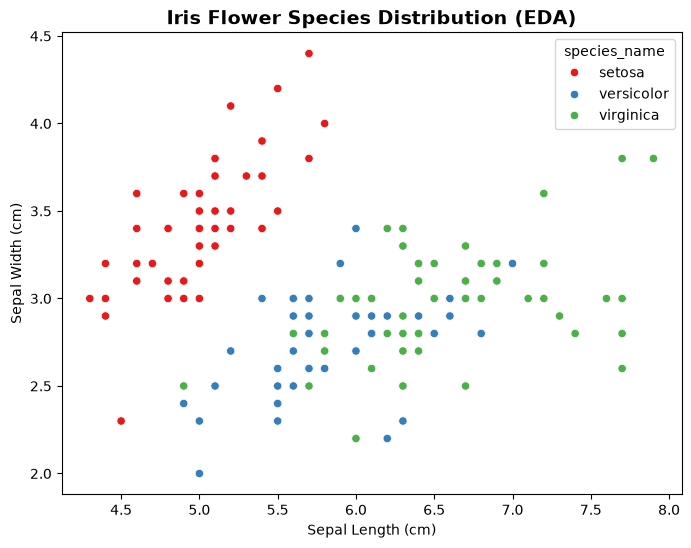

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



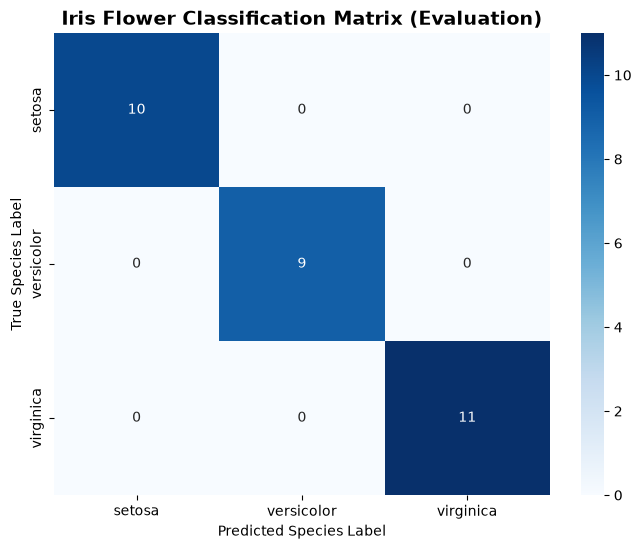

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load Data
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
species_names = iris.target_names
df['species_name'] = df['species'].map({i: name for i, name in enumerate(species_names)})

# 2. Visualization: Scatter Plot (Fig 1)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='species_name', data=df, palette='Set1')
plt.title('Iris Flower Species Distribution (EDA)', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

# 3. Model Training & Evaluation
X = df.drop(['species', 'species_name'], axis=1)
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Print Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=species_names))

# 4. Visualization: Confusion Matrix (Fig 2)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=species_names, yticklabels=species_names)
plt.title('Iris Flower Classification Matrix (Evaluation)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Species Label')
plt.ylabel('True Species Label')
plt.show()